# Random Forest 분석

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import matplotlib.pyplot as plt
import platform

# 한글 폰트 설정
if platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows': # Windows
    plt.rc('font', family='Malgun Gothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print(f"현재 설정된 폰트: {plt.rcParams['font.family']}")

현재 설정된 폰트: ['AppleGothic']


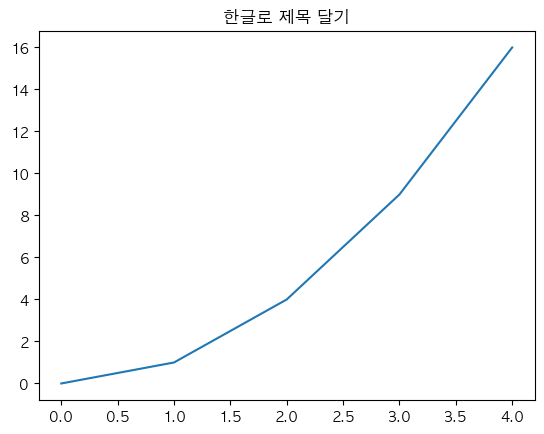

In [4]:
# 맥 한글 설정 아래 블로그서 가져옴
# https://wannabe00.tistory.com/entry/Mac%EC%97%90%EC%84%9C-Matplotlib-%EC%82%AC%EC%9A%A9-%EC%8B%9C-%ED%95%9C%EA%B8%80-%EA%B9%A8%EC%A7%90-%ED%95%B4%EA%B2%B0

from matplotlib import rc
import matplotlib.pyplot as plt

rc('font', family='AppleGothic') 			## 이 두 줄을 
plt.rcParams['axes.unicode_minus'] = False  ## 추가해줍니다. 

plt.figure()
plt.plot([i**2 for i in range(5)])
plt.title('한글로 제목 달기')
plt.show()          

### 데이터 재확인

In [5]:
import pandas as pd
df = pd.read_csv('./data/최종전처리.csv', encoding='cp949')
df

,Unnamed: 0,시도,일시,fire,평균기온(°C),최고기온(°C),일강수량(mm),평균 상대습도(%),최대 풍속(m/s),평균 풍속(m/s),최저기온(°C),일 최심적설(cm),실효습도,년도,논_비율,밭_비율,도시_산림_인접지수
0,0,경북,2016-01-03,1,4.376923,16.3,0.0,72.415385,6.5,1.184615,-6.6,0.0,59.201499,2016,14.049405,19.069746,10.158780
1,1,경북,2016-01-04,0,5.192308,12.9,0.0,50.807692,8.3,2.715385,-6.2,0.0,55.198808,2016,14.049405,19.069746,10.158780
2,2,경북,2016-01-05,0,0.423077,7.0,0.0,33.076923,8.1,2.646154,-7.0,0.0,46.443746,2016,14.049405,19.069746,10.158780
3,3,경북,2016-01-06,1,0.084615,7.0,0.0,46.515385,9.6,2.976923,-9.8,0.0,43.977776,2016,14.049405,19.069746,10.158780
4,4,경북,2016-01-07,0,-0.030769,6.4,0.0,44.192308,8.1,3.092308,-9.2,0.0,41.731961,2016,14.049405,19.069746,10.158780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62013,63262,제주,2025-12-27,0,4.200000,9.4,0.0,59.325000,6.1,2.625000,-2.8,0.0,54.115659,2025,0.001604,7.444119,6.744372
62014,63263,제주,2025-12-28,0,8.950000,13.7,0.0,53.875000,12.7,2.800000,1.0,0.0,51.877249,2025,0.001604,7.444119,6.744372
62015,63264,제주,2025-12-29,0,12.325000,17.3,0.0,60.600000,11.5,4.400000,5.0,0.0,52.197272,2025,0.001604,7.444119,6.744372
62016,63265,제주,2025-12-30,0,8.325000,15.8,0.0,51.725000,10.3,3.700000,3.6,0.0,49.414664,2025,0.001604,7.444119,6.744372


In [6]:
df = df.drop(['Unnamed: 0'],axis=1)

df['일시'] = pd.to_datetime(df['일시'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 62018 entries, 0 to 62017
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   시도          62018 non-null  str           
 1   일시          62018 non-null  datetime64[us]
 2   fire        62018 non-null  int64         
 3   평균기온(°C)    62018 non-null  float64       
 4   최고기온(°C)    62018 non-null  float64       
 5   일강수량(mm)    62018 non-null  float64       
 6   평균 상대습도(%)  62018 non-null  float64       
 7   최대 풍속(m/s)  62018 non-null  float64       
 8   평균 풍속(m/s)  62018 non-null  float64       
 9   최저기온(°C)    62018 non-null  float64       
 10  일 최심적설(cm)  62018 non-null  float64       
 11  실효습도        62018 non-null  float64       
 12  년도          62018 non-null  int64         
 13  논_비율        62018 non-null  float64       
 14  밭_비율        62018 non-null  float64       
 15  도시_산림_인접지수  62018 non-null  float64       
dtypes: datetime64[us](1), float64(12)

In [7]:
print(df.isnull().sum())

시도            0
일시            0
fire          0
평균기온(°C)      0
최고기온(°C)      0
일강수량(mm)      0
평균 상대습도(%)    0
최대 풍속(m/s)    0
평균 풍속(m/s)    0
최저기온(°C)      0
일 최심적설(cm)    0
실효습도          0
년도            0
논_비율          0
밭_비율          0
도시_산림_인접지수    0
dtype: int64


# RF(1) 일반 (balanced X)

In [8]:
# 데이터 분리
from sklearn.model_selection import train_test_split

X = df.drop(['fire', '시도', '일시', '년도', '최고기온(°C)', '최저기온(°C)'], axis=1)
y = df['fire']
print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)


(62018, 10) (62018,)


### 정확도(1)

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(max_depth=8, random_state=0)

rf_clf.fit(X_train, y_train)    # 유방암 데이터

rf_clf.score(X_train, y_train), rf_clf.score(X_test, y_test)

(0.9372003525895987, 0.9316994517897452)

### 특성 중요도(1)

In [10]:
rf_clf.feature_importances_

fesat_impt_ser = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
fesat_impt_ser

실효습도          0.280542
밭_비율          0.174686
논_비율          0.160635
평균 상대습도(%)    0.139046
평균기온(°C)      0.087424
도시_산림_인접지수    0.064108
일강수량(mm)      0.032500
최대 풍속(m/s)    0.030406
평균 풍속(m/s)    0.024802
일 최심적설(cm)    0.005852
dtype: float64

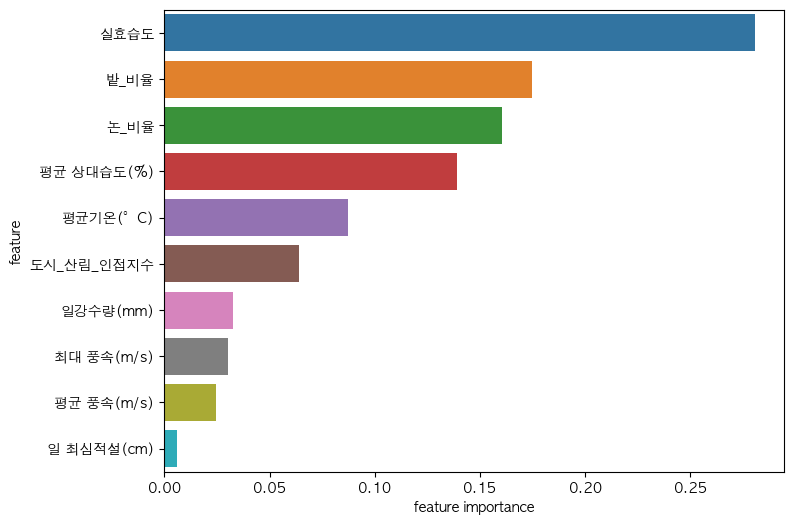

In [11]:
plt.figure(figsize=(8,6))
sns.barplot(
    x=fesat_impt_ser,
    y=fesat_impt_ser.index,
    hue=fesat_impt_ser.index,
)
plt.xlabel('feature importance')
plt.ylabel('feature')

plt.savefig('./graphs/RF_normal_feature_importance.png', dpi=300, bbox_inches='tight')

plt.show()

### Confusion Matrix (1)

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

# 모델 예측 결과 확인
y_pred = rf_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96     14249
           1       0.70      0.28      0.40      1256

    accuracy                           0.93     15505
   macro avg       0.82      0.63      0.68     15505
weighted avg       0.92      0.93      0.92     15505



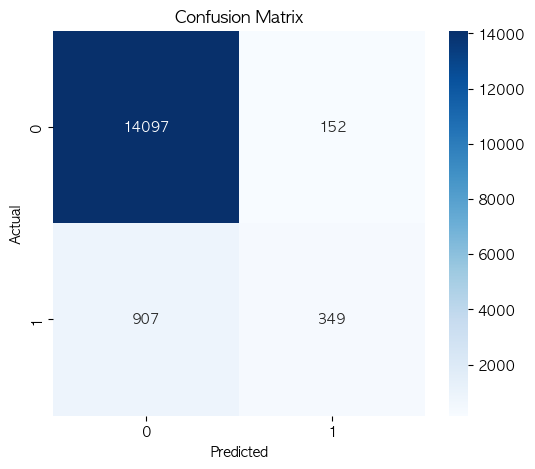

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('./graphs/RF_normal_Confusion_Matrix.png', dpi=300, bbox_inches='tight')

plt.show()

### ROC 곡선 (1)

In [14]:
# 모델이 각 클래스(0, 1)에 속할 확률을 계산하는 코드
pred_proba_1 = rf_clf.predict_proba(X_test)[:, 1]

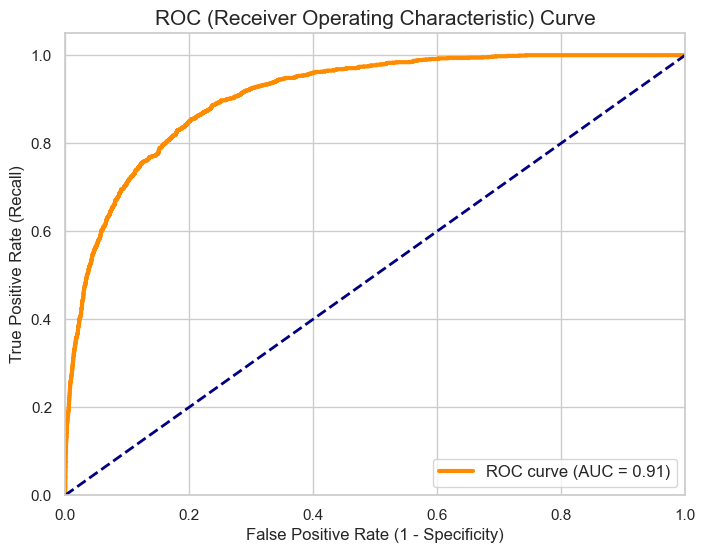

In [15]:
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# 스타일 설정
sns.set_theme(style="whitegrid")

# ROC 계산
fpr, tpr, thresholds = roc_curve(y_test, pred_proba_1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# ROC 곡선 그리기 (굵기 조절 및 색상 강조)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 대각선 점선 (Random Guess 기준선)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 축 범위 및 라벨 설정
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC (Receiver Operating Characteristic) Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)

plt.savefig('./graphs/RF_normal_ROC_curve.png', dpi=300, bbox_inches='tight')

plt.show()

# RF(2) Balanced

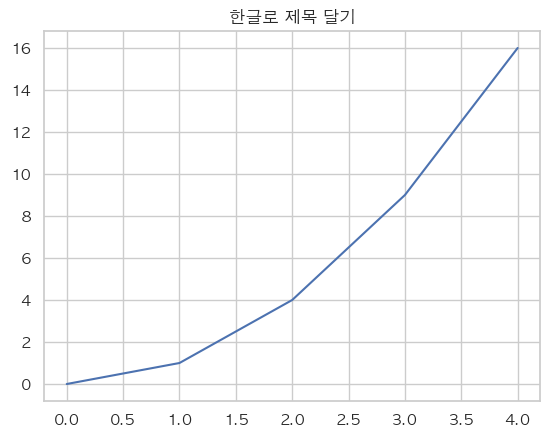

In [16]:
# 맥 한글 설정 아래 블로그서 가져옴
# https://wannabe00.tistory.com/entry/Mac%EC%97%90%EC%84%9C-Matplotlib-%EC%82%AC%EC%9A%A9-%EC%8B%9C-%ED%95%9C%EA%B8%80-%EA%B9%A8%EC%A7%90-%ED%95%B4%EA%B2%B0

from matplotlib import rc
import matplotlib.pyplot as plt

rc('font', family='AppleGothic') 			## 이 두 줄을 
plt.rcParams['axes.unicode_minus'] = False  ## 추가해줍니다. 

plt.figure()
plt.plot([i**2 for i in range(5)])
plt.title('한글로 제목 달기')
plt.show()          

In [17]:
# 데이터 분리
from sklearn.model_selection import train_test_split

X = df.drop(['fire', '시도', '일시', '년도', '최고기온(°C)', '최저기온(°C)'], axis=1)
y = df['fire']
print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)


(62018, 10) (62018,)


### 정확도(2)

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(max_depth=8, random_state=0, class_weight='balanced')

rf_clf.fit(X_train, y_train) 

rf_clf.score(X_train, y_train), rf_clf.score(X_test, y_test)

(0.854040805796229, 0.8434053531118993)

### 특성 중요도(2)

In [48]:
rf_clf.feature_importances_

fesat_impt_ser = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
fesat_impt_ser

실효습도          0.303220
평균 상대습도(%)    0.189922
논_비율          0.175538
밭_비율          0.168110
평균기온(°C)      0.051297
일강수량(mm)      0.036657
도시_산림_인접지수    0.032086
최대 풍속(m/s)    0.023025
평균 풍속(m/s)    0.017644
일 최심적설(cm)    0.002500
dtype: float64

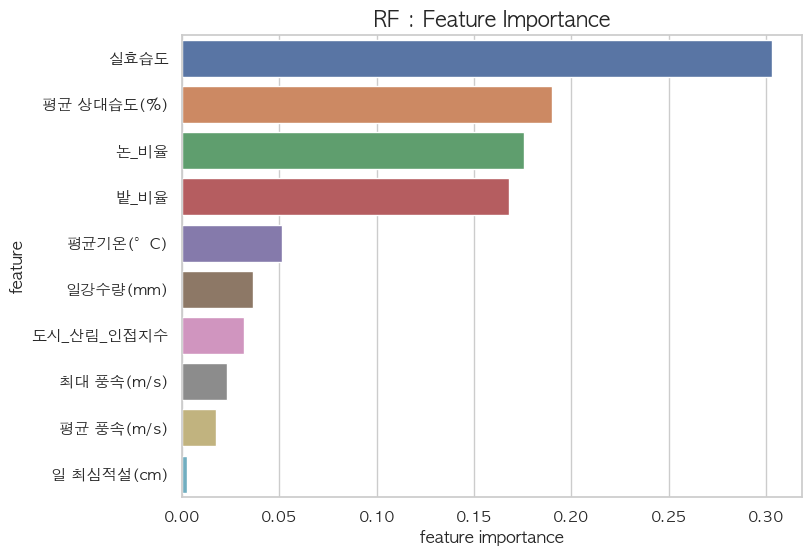

In [49]:
plt.figure(figsize=(8,6))
sns.barplot(
    x=fesat_impt_ser,
    y=fesat_impt_ser.index,
    hue=fesat_impt_ser.index,
)
plt.xlabel('feature importance')
plt.ylabel('feature')
plt.title('RF : Feature Importance', fontsize=15)

plt.savefig('./graphs/RF_balanced_feature_importance.png', dpi=300, bbox_inches='tight')

plt.show()

### Confusion Matrix (2)

In [50]:
from sklearn.metrics import classification_report, confusion_matrix

# 모델 예측 결과 확인
y_pred = rf_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.85      0.91     14249
           1       0.31      0.78      0.45      1256

    accuracy                           0.84     15505
   macro avg       0.65      0.81      0.68     15505
weighted avg       0.92      0.84      0.87     15505



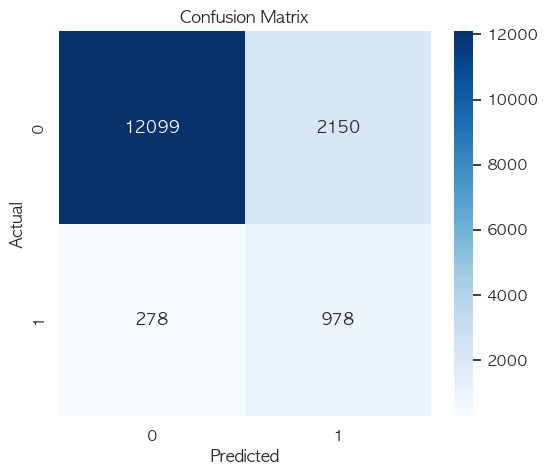

In [51]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.savefig('./graphs/RF_balanced_Confusion_Matrix.png', dpi=300, bbox_inches='tight')

plt.show()

### ROC 곡선 (2)

In [52]:
# 모델이 각 클래스(0, 1)에 속할 확률을 계산하는 코드
pred_proba_1 = rf_clf.predict_proba(X_test)[:, 1]

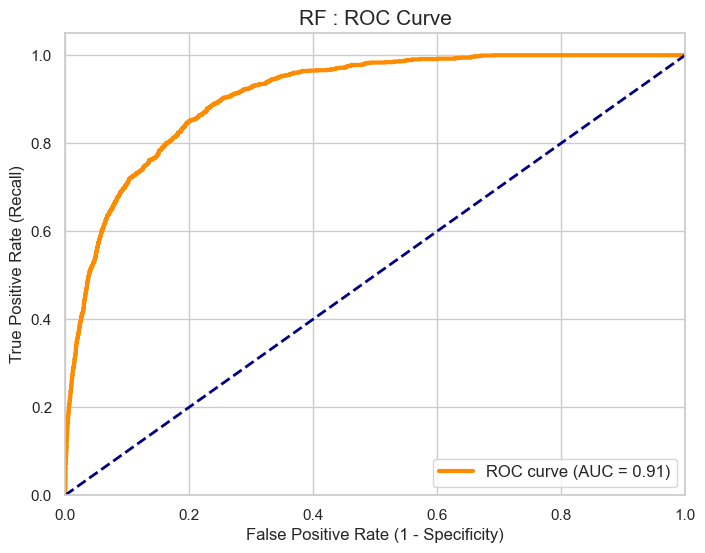

0.9086839203823892


In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# 스타일 설정
sns.set_theme(style="whitegrid")

# ROC 계산
fpr, tpr, thresholds = roc_curve(y_test, pred_proba_1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# ROC 곡선 그리기 (굵기 조절 및 색상 강조)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 대각선 점선 (Random Guess 기준선)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 축 범위 및 라벨 설정
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('RF : ROC Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)

plt.savefig('./graphs/RF_balanced_ROC_curve.png', dpi=300, bbox_inches='tight')

plt.show()

print(roc_auc)

# 최적의 임계값 찾기

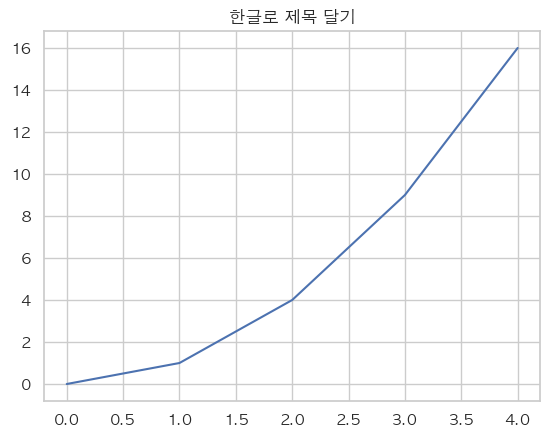

In [54]:
# 맥 한글 설정 아래 블로그서 가져옴
# https://wannabe00.tistory.com/entry/Mac%EC%97%90%EC%84%9C-Matplotlib-%EC%82%AC%EC%9A%A9-%EC%8B%9C-%ED%95%9C%EA%B8%80-%EA%B9%A8%EC%A7%90-%ED%95%B4%EA%B2%B0

from matplotlib import rc
import matplotlib.pyplot as plt

rc('font', family='AppleGothic') 			## 이 두 줄을 
plt.rcParams['axes.unicode_minus'] = False  ## 추가해줍니다. 

plt.figure()
plt.plot([i**2 for i in range(5)])
plt.title('한글로 제목 달기')
plt.show()          

### 1. Youden's J statistic (가장 대중적인 방법)

ROC 커브에서 대각선(무작위 모델)으로부터 수직 거리가 가장 먼 지점을 찾는 방법입니다. 즉, 헛다리(FPR)는 적게 짚으면서 실제 상황(TPR)은 가장 잘 맞추는 지점입니다.

J=True Positive Rate (Recall)−False Positive Rate

In [55]:
# J 지표가 최대인 지점의 인덱스 찾기
J = tpr - fpr
ix = np.argmax(J)
best_thresh = thresholds[ix]

print(f'Best Threshold (Youden): {best_thresh:.4f}')

Best Threshold (Youden): 0.4216


--- Threshold: 0.3688 적용 결과 ---
              precision    recall  f1-score   support

           0       0.99      0.76      0.86     14249
           1       0.25      0.89      0.39      1256

    accuracy                           0.77     15505
   macro avg       0.62      0.82      0.62     15505
weighted avg       0.93      0.77      0.82     15505



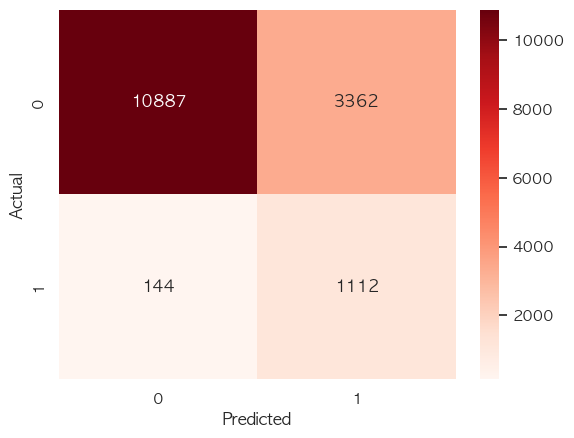

In [56]:
# 1. 찾은 최적 임계값 적용
best_thresh = 0.3688
y_pred_new = (pred_proba_1 >= best_thresh).astype(int)

# 2. 결과 출력
from sklearn.metrics import classification_report, confusion_matrix
print(f"--- Threshold: {best_thresh} 적용 결과 ---")
print(classification_report(y_test, y_pred_new))

# 3. 혼동 행렬 시각화 (선택 사항)
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, y_pred_new), annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('./graphs/Finding_b_threshold_1.png', dpi=300, bbox_inches='tight')

plt.show()

In [57]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# from sklearn.metrics import confusion_matrix, precision_score, recall_score

# # 1. 데이터 준비 (이미지 수치 기준: Threshold 0.3688)
# # 실제 데이터 변수(y_test, y_pred_new)를 그대로 사용하시면 됩니다.
# cm = confusion_matrix(y_test, y_pred_new)

# # 지표 직접 계산
# precision = precision_score(y_test, y_pred_new)
# recall = recall_score(y_test, y_pred_new)

# # 2. 각 칸에 들어갈 라벨 설정
# group_names = ['정상 적중', '오보 (FP)', '미탐지 (FN)', '화재 적중']
# group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
# group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]

# labels = [f"{v1}\n{v2}\n({v3})" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
# labels = np.asarray(labels).reshape(2,2)

# # 3. 그래프 그리기
# plt.figure(figsize=(9, 7))
# sns.heatmap(cm, annot=labels, fmt='', cmap='Reds', cbar=False, annot_kws={"size": 12})

# # 제목에 핵심 지표 명시 (이게 포인트입니다!)
# plt.title(f'Confusion Matrix (Threshold: {best_thresh})\n' + 
#           f'[ 정밀도(Precision): {precision:.2f}  |  재현율(Recall): {recall:.2f} ]', 
#           fontsize=14, pad=20)

# plt.xlabel('예측값 (Predicted)', fontsize=12)
# plt.ylabel('실제값 (Actual)', fontsize=12)
# plt.xticks([0.5, 1.5], ['정상(0)', '화재(1)'])
# plt.yticks([0.5, 1.5], ['정상(0)', '화재(1)'])

# # 4. 저장 및 출력
# plt.savefig('./graph/Final_Analysis_Matrix.png', dpi=300, bbox_inches='tight')
# plt.show()

### 2. Precision-Recall Curve (불균형 데이터 추천)

In [58]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds_pr = precision_recall_curve(y_test, pred_proba_1)

# F1-score 계산
f1_scores = (2 * precisions * recalls) / (precisions + recalls)
ix_f1 = np.argmax(f1_scores)
best_thresh_f1 = thresholds_pr[ix_f1]

print(f'Best Threshold (F1-score): {best_thresh_f1:.4f}')

Best Threshold (F1-score): 0.7527


--- Threshold: 0.7275 적용 결과 ---
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     14249
           1       0.45      0.63      0.53      1256

    accuracy                           0.91     15505
   macro avg       0.71      0.78      0.74     15505
weighted avg       0.92      0.91      0.91     15505



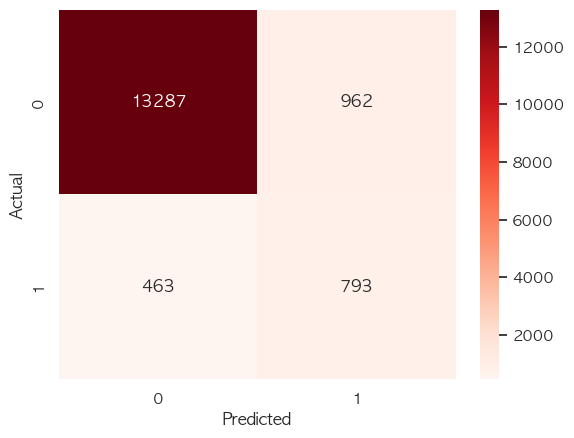

In [59]:
# 1. 찾은 최적 임계값 적용
best_thresh = 0.7275
y_pred_new = (pred_proba_1 >= best_thresh).astype(int)

# 2. 결과 출력
from sklearn.metrics import classification_report, confusion_matrix
print(f"--- Threshold: {best_thresh} 적용 결과 ---")
print(classification_report(y_test, y_pred_new))

# 3. 혼동 행렬 시각화 (선택 사항)
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, y_pred_new), annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.savefig('./graphs/Finding_b_threshold_2.png', dpi=300, bbox_inches='tight')

plt.show()

# Optuna (최적의 하이퍼 파라미터 찾기)

In [60]:
# !pip install optuna

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

def objective(trial):
    # 1. 탐색할 하이퍼파라미터 범위 설정
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 3, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight': 'balanced', 
        'random_state': 42
    }
    
    # 2. 모델 생성
    model = RandomForestClassifier(**params)
    
    # 3. 교차 검증 수행 (scoring을 'roc_auc'로 변경)
    # roc_auc는 클래스 확률값을 기반으로 모델의 분류 능력을 종합 평가합니다.
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    
    return score

# 4. 최적화 실행
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

# 5. 결과 확인
print("최적의 하이퍼파라미터:", study.best_params)
print("최고 ROC-AUC Score:", study.best_value)

# 6. 최적의 파라미터로 최종 모델 학습 및 확률 예측
best_rf_model = RandomForestClassifier(**study.best_params, class_weight='balanced', random_state=42)
best_rf_model.fit(X_train, y_train)

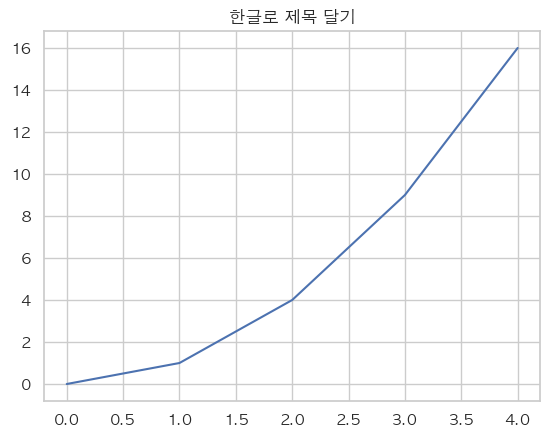

In [62]:
# 맥 한글 설정 아래 블로그서 가져옴
# https://wannabe00.tistory.com/entry/Mac%EC%97%90%EC%84%9C-Matplotlib-%EC%82%AC%EC%9A%A9-%EC%8B%9C-%ED%95%9C%EA%B8%80-%EA%B9%A8%EC%A7%90-%ED%95%B4%EA%B2%B0

from matplotlib import rc
import matplotlib.pyplot as plt

rc('font', family='AppleGothic') 			## 이 두 줄을 
plt.rcParams['axes.unicode_minus'] = False  ## 추가해줍니다. 

plt.figure()
plt.plot([i**2 for i in range(5)])
plt.title('한글로 제목 달기')
plt.show()          

In [63]:
# 데이터 분리
from sklearn.model_selection import train_test_split

X = df.drop(['fire', '시도', '일시', '년도', '최고기온(°C)', '최저기온(°C)'], axis=1)
y = df['fire']
print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)


(62018, 10) (62018,)


### 정확도(3)

In [64]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=286,           # 트리의 개수
    criterion='gini',           # 불순도 지표
    max_depth=23,               # 트리의 최대 깊이
    min_samples_split=12,       # 노드 분할을 위한 최소 샘플 수
    min_samples_leaf=8,         # 리프 노드가 되기 위한 최소 샘플 수
    max_features='sqrt',        # 최적의 분할을 위해 고려할 특성 수
    bootstrap=True,             # 샘플 중복 허용(복원 추출)
    random_state=42,            # 결과 재현을 위한 고정값
    class_weight='balanced',    # ⭐ 불균형 데이터 가중치 자동 조절
    n_jobs=-1                   # 모든 CPU 코어 사용 (학습 속도 향상)
)

rf_clf.fit(X_train, y_train) 

rf_clf.score(X_train, y_train), rf_clf.score(X_test, y_test)

(0.9434996667598305, 0.908610125765882)

### 특성 중요도(3)

In [65]:
rf_clf.feature_importances_

fesat_impt_ser = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
fesat_impt_ser

실효습도          0.269185
평균 상대습도(%)    0.168835
밭_비율          0.151307
논_비율          0.141892
평균기온(°C)      0.080324
도시_산림_인접지수    0.052054
최대 풍속(m/s)    0.049406
평균 풍속(m/s)    0.047098
일강수량(mm)      0.036468
일 최심적설(cm)    0.003432
dtype: float64

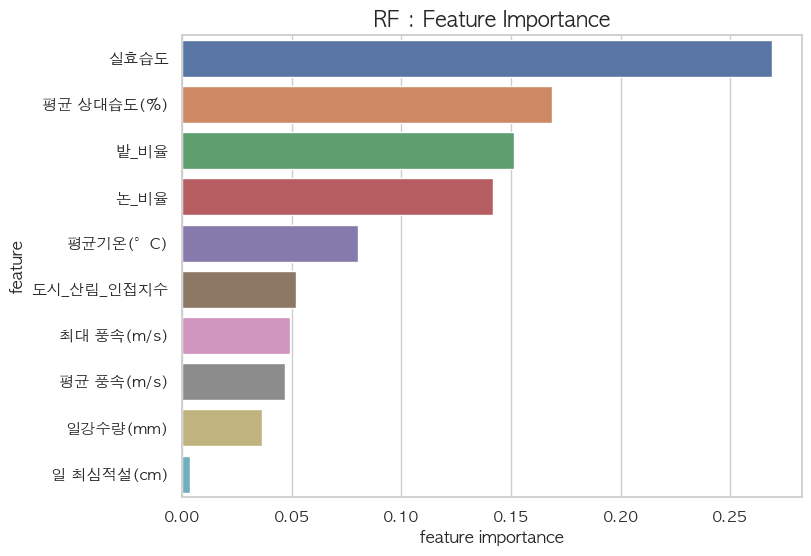

In [66]:
plt.figure(figsize=(8,6))
sns.barplot(
    x=fesat_impt_ser,
    y=fesat_impt_ser.index,
    hue=fesat_impt_ser.index,
)
plt.xlabel('feature importance')
plt.ylabel('feature')
plt.title('RF : Feature Importance', fontsize=15)

plt.savefig('./graphs/RF_final_feature_importance.png', dpi=300, bbox_inches='tight')

plt.show()

### Confusion Matrix (3)

In [67]:
from sklearn.metrics import classification_report, confusion_matrix

# 모델 예측 결과 확인
y_pred = rf_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95     14249
           1       0.46      0.68      0.55      1256

    accuracy                           0.91     15505
   macro avg       0.71      0.80      0.75     15505
weighted avg       0.93      0.91      0.92     15505



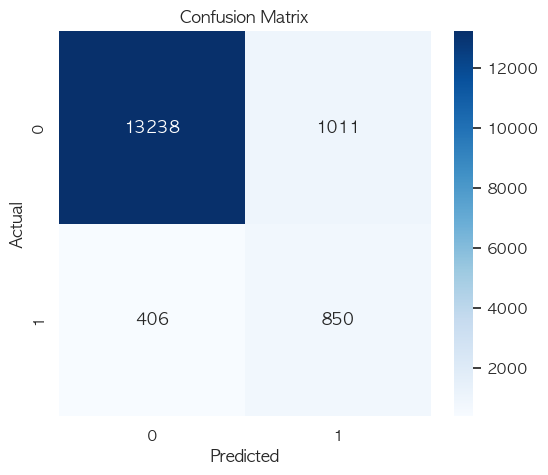

In [68]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.savefig('./graphs/RF_final_Confusion_Matrix.png', dpi=300, bbox_inches='tight')

plt.show()

### ROC 곡선 (3)

In [69]:
# 모델이 각 클래스(0, 1)에 속할 확률을 계산하는 코드
pred_proba_1 = rf_clf.predict_proba(X_test)[:, 1]

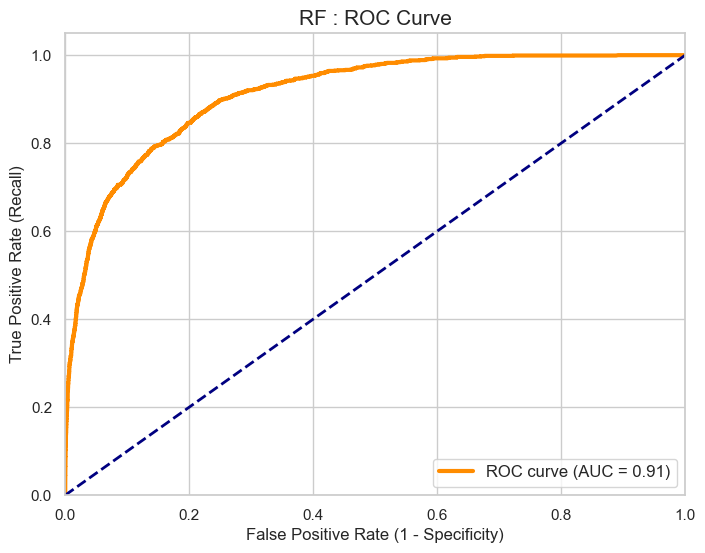

0.9125233617913963


In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# 스타일 설정
sns.set_theme(style="whitegrid")

# ROC 계산
fpr, tpr, thresholds = roc_curve(y_test, pred_proba_1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# ROC 곡선 그리기 (굵기 조절 및 색상 강조)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 대각선 점선 (Random Guess 기준선)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 축 범위 및 라벨 설정
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('RF : ROC Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)

plt.savefig('./graphs/RF_final_ROC_curve.png', dpi=300, bbox_inches='tight')

plt.show()

print(roc_auc)